In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform


In [2]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

PCAHeaders = [str(i) for i in range(0,8)]

pumpList = PCAData["Well Run"].unique()


/tmp/ipykernel_75344/452915461.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [3]:
PCAData[["Transformed Radius","VibNormX","VibNormY"]] = 0.0
#modelPlay = np.array([])

for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump]#.copy()

    # pumpData["Shutdown"] = (pumpData["Well_down"] != pumpData["Well_down"].shift(1).fillna(pumpData["Well_down"].iloc[-1])) #differentiates well down blocks

    # pumpData["CumShut"] = pumpData["Shutdown"].cumsum() #group names them

    # testSize =pumpData.groupby("CumShut") #groupby execution

    # blockSize = testSize.size() #gets size of each group
    # real = blockSize[testSize["Well_down"].last()==0] #selects only online runs
   
    
    # modelPlay = np.concat([modelPlay,real.to_numpy()])


    PCAData.loc[pumpData.index,"Transformed Radius"] = li.BoxCoxProccess(pumpData,"Radius")
    PCAData.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
    PCAData.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")


#modelData = PCAData.loc[PCAData["Well_down"]==0].copy() #dados de operação apenas, dados desligados não são considerados
#modelData = modelData.sort_values(["Well Run","time"])


In [4]:
mainSeed = 19971215
np.random.seed()#mainSeed)

proportion = 0.75

X_train,trainLength, X_test, testLength = li.Splitter(pumpList,proportion,PCAData)

totalLength = np.concatenate([trainLength,testLength])

modelData = pd.concat([X_train,X_test])

/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)


In [26]:
n = [6, 4, 10]

In [27]:
modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0])
li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
print(modelSq.get_stationary_distribution())
PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))

12.810030325284519
[0.2637719  0.11627368 0.0234324  0.18512623 0.23784257 0.17355322]


In [42]:
modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1])
li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
print(modelVib.get_stationary_distribution())
PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

14.531693348451025
[0.39154906 0.19806656 0.13477732 0.27560706]


In [29]:
modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2])
li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
print(modelTot.get_stationary_distribution())
PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))

15.024272948062396
[0.04879176 0.10595129 0.00175653 0.10471437 0.13792866 0.1704188
 0.04727472 0.04090616 0.23405424 0.10820347]


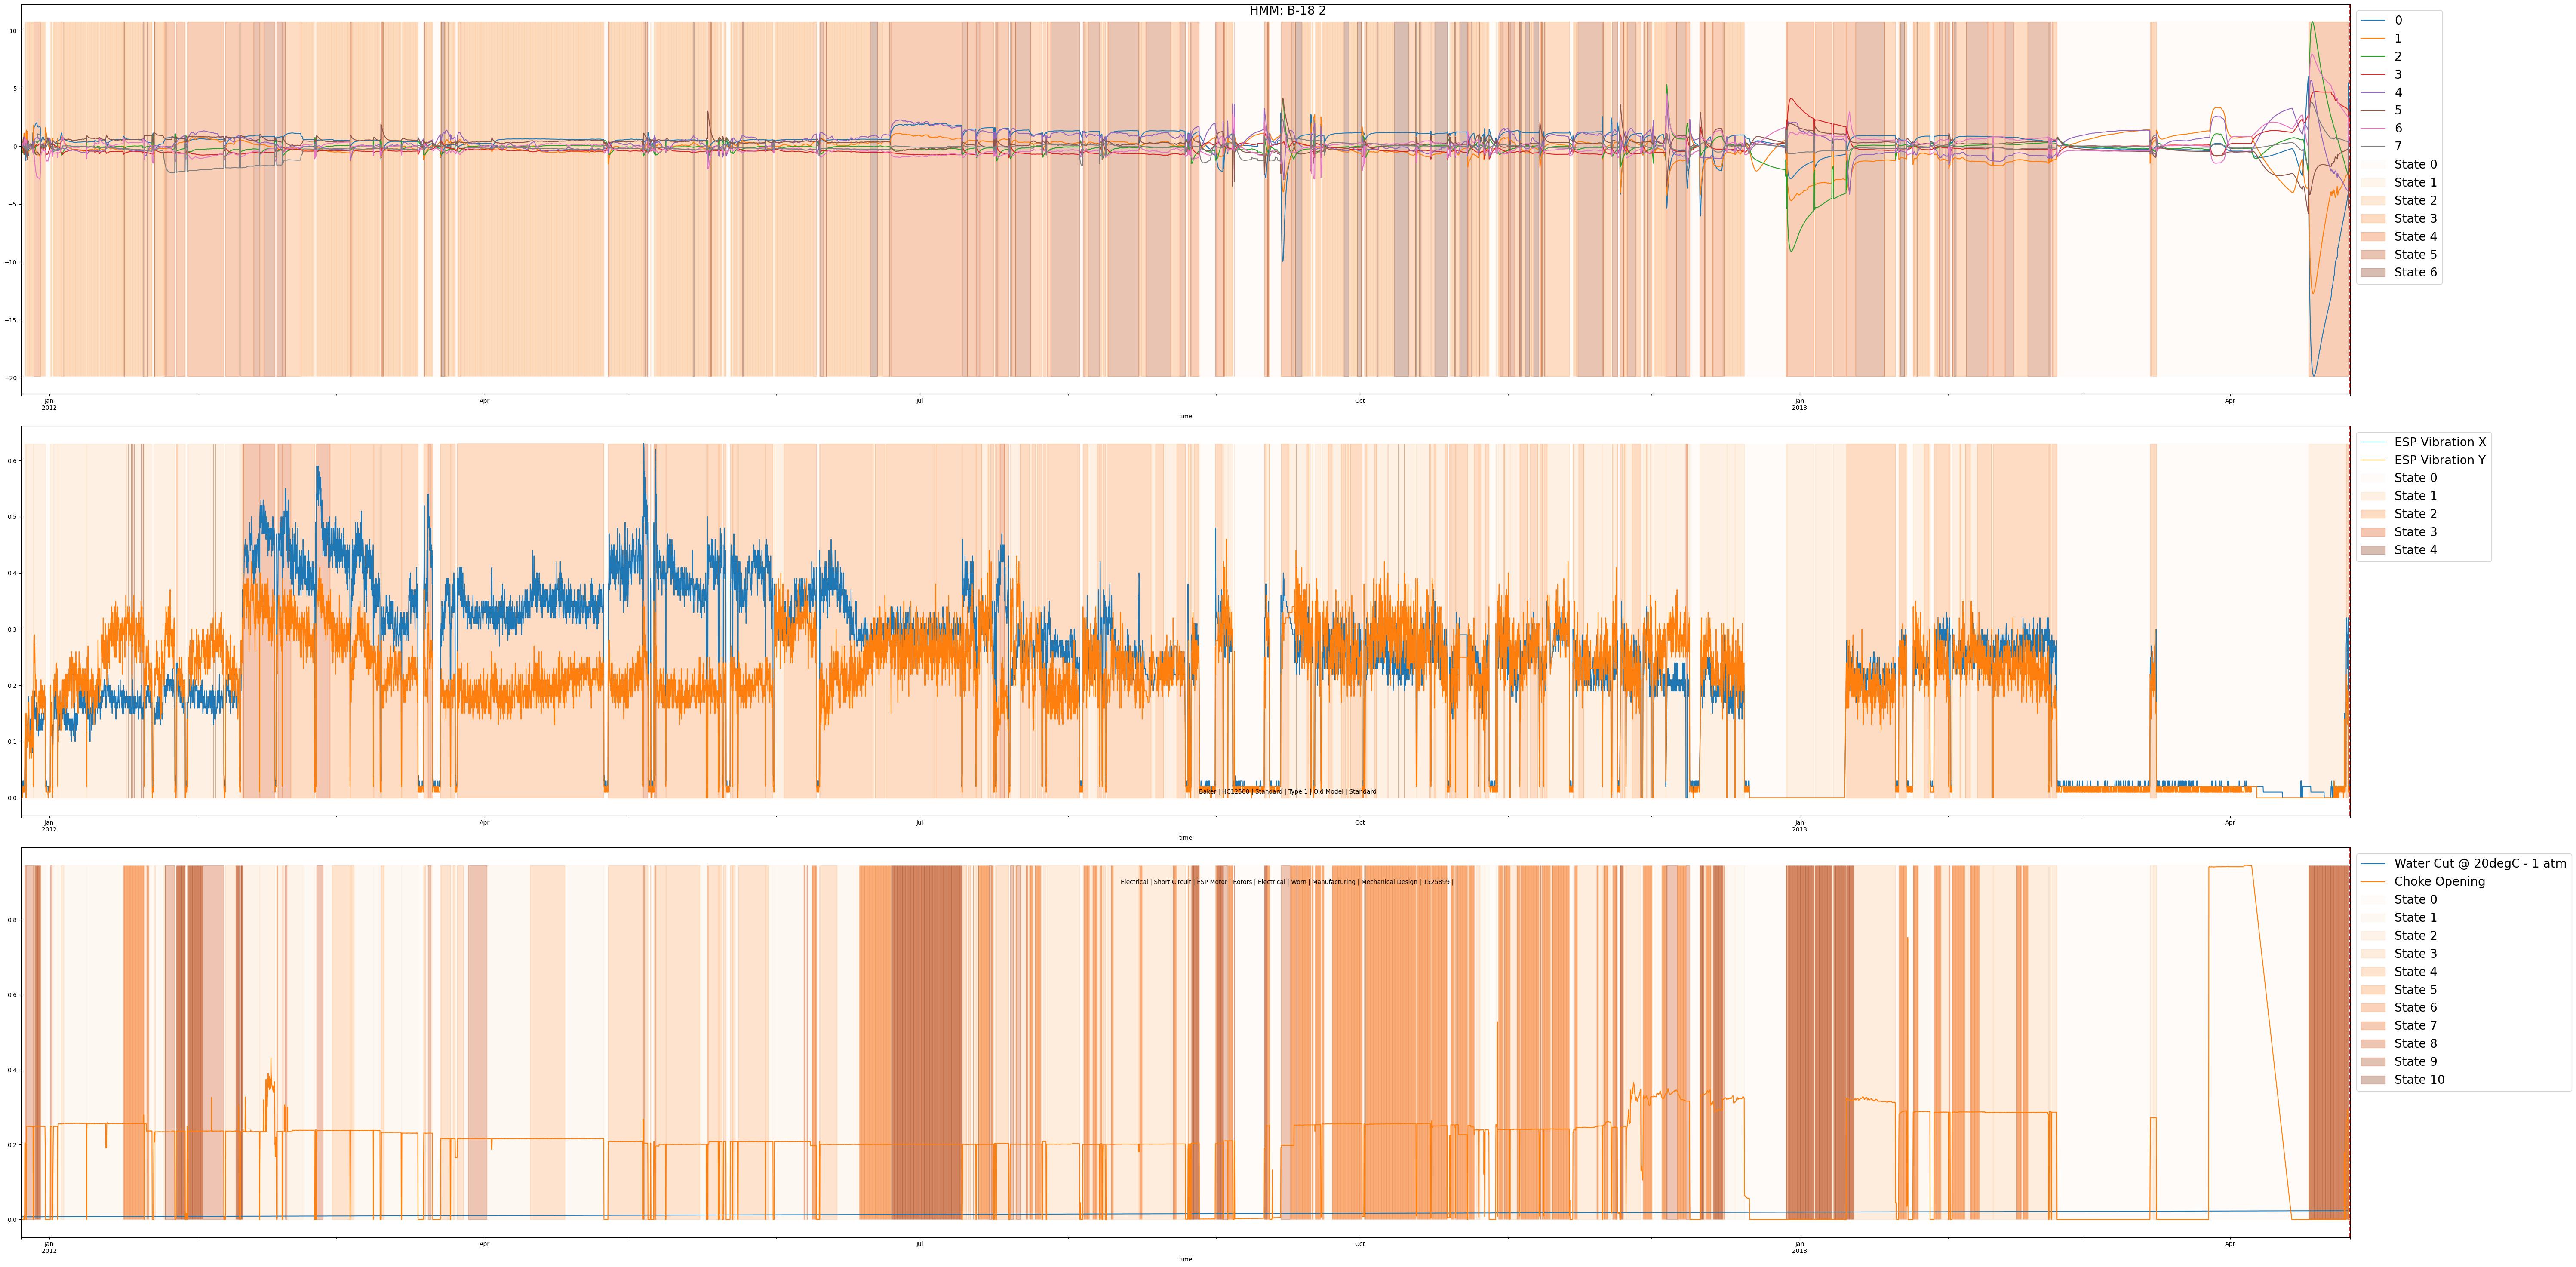

In [30]:
pump = pumpList[0]

pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)

In [31]:
for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
    fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
    fig.savefig("../imagensHMM/"+pump)
    plt.close()

<Axes: >

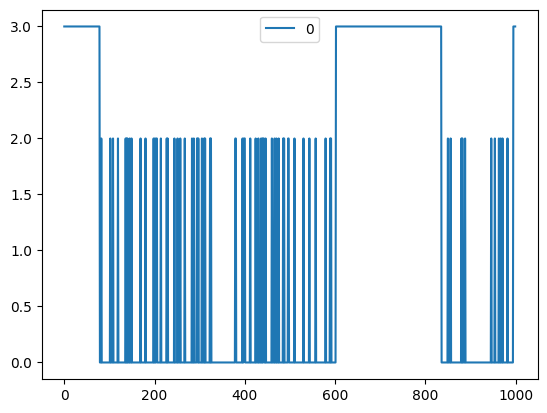

In [41]:
pd.DataFrame(modelVib.sample(1000)[1]).plot()

In [9]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Converte para um DataFrame
# df = pd.DataFrame(modelSq.predict_proba(X_test["Transformed Radius"].to_numpy().reshape(-1,1),testLength), columns=["Estado 1", "Estado 2", "Estado 3"])

# # Índices de tempo
# time = np.arange(len(df))

# # Criar figura
# fig, ax = plt.subplots(figsize=(20, 6))

# # Cores para os estados
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# # Gráfico de área empilhada com transparência (alpha)
# ax.stackplot(time, df.T, labels=df.columns, colors=colors, alpha=0.3)
# ax.legend(title="Estados", loc='upper left')

# # Configurações do gráfico
# ax.set_xlabel("Tempo")
# ax.set_ylabel("Probabilidade Empilhada (%)")
# ax.set_title("Probabilidades do HMM (100% Stacked Area Chart)")

# plt.ylim(0, 2)  # Mantém o eixo Y de 0 a 1 (100%)

# # Exibir o gráfico
# plt.show()


In [10]:
# for pump in pumpList:
   
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     fig, axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)

#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [11]:
# import dynamax.hidden_markov_model as hmm


# model = hmm.LinearAutoregressiveHMM(num_states=4,emission_dim=5)
# model.fit_em()


#  pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     pumpData["time"] = pd.to_datetime(pumpData["time"])
#     pumpData.set_index("time",inplace=True)

#     pumpData = pumpData.asfreq('h',fill_value=0)

#     pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])

#     fig, ax = plt.subplots(4,1, figsize=(50,15))

#     pumpData[PCAHeaders].plot(ax=ax[0])


#     # Preenchendo as áreas de acordo com os estados
#     for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax[0].fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"Estado {state}")
        
#     ax[0].legend(loc='upper left',bbox_to_anchor=(1, 1))


#     # for shut in pumpData["Shutdown"].loc[pumpData["Shutdown"] == True].index:
#     #       ax[0].axvline(x=shut, color='black', linestyle='-', linewidth=0.5)





#     norm = mcolors.Normalize(vmin=-6, vmax=6)

#     its = ax[3].pcolor(pumpData[PCAHeaders].T,cmap='hsv', norm=norm)
#     ax[3].grid(axis="y",linewidth=1,color="black")
#     ax[3].tick_params(axis='both', which='both', length=0)  # Remove ticks
#     ax[3].set_xticklabels([])  # Remove labels no eixo x


#     ax[3].set_title(str(pumpData["Pump Info"].iloc[0])+" "+str(pumpData["Failure Info"].iloc[0]))




#     if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#             failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#             ax[3].axvline(x=failureX, color='red', linestyle='--', linewidth=1)


#     fig.colorbar(its,ax=ax[3],orientation='horizontal',shrink=0.5)


#     fig.suptitle("HMM e Imshow: " + pump);
#     plt.tight_layout()
#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [12]:
# pump = pumpList[0]
# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# plt.rcParams['font.size'] = 15.0
# pumpData["time"] = pd.to_datetime(pumpData["time"])
# pumpData.set_index("time",inplace=True)

# pumpData = pumpData.asfreq('h',fill_value=0)

# pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])


# fig, ax = plt.subplots(1,1, figsize=(20,10))

# pumpData[PCAHeaders].plot(ax=ax)


# # Preenchendo as áreas de a
# # cordo com os estados
# for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax.fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"State {state}")

#         ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)



# if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#         #failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#         ax.axvline(x=pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)


# fig.suptitle("HMM: " + pump,fontsize=20);
# fig.savefig("imagens/relatorio/hmm")